In [19]:
from pathlib import Path


def export_notebook_to_markdown(notebook_name, output_dir='../docs'):
    """Export a notebook's markdown cells and rendered code outputs to a Markdown file.

    Parameters
    ----------
    notebook_name : str
        Notebook stem to read from the current directory, without the .ipynb suffix.
    output_dir : str, default '../docs'
        Directory where the generated Markdown file will be written.

    Notes
    -----
    Markdown cell sources are copied as-is. Code cell inputs are skipped, but common
    rendered outputs are preserved, including plain text, markdown, HTML, and inline
    PNG images encoded as data URLs.
    """

    import nbformat

    # Load the notebook
    if Path(notebook_name+'.ipynb').exists():
        nb = nbformat.read(notebook_name+'.ipynb', as_version=4)
    else:
        raise FileNotFoundError(f"Notebook {notebook_name}.ipynb not found")

    md_lines = []

    for cell in nb.cells:
        if cell.cell_type == "markdown":
            # Keep markdown content as-is
            md_lines.append(cell.source)
        elif cell.cell_type == "code":
            # Keep only outputs
            for output in cell.get("outputs", []):
                if output.output_type == "stream":
                    md_lines.append(f"```\n{output.text.strip()}\n```")
                elif output.output_type == "execute_result" and "text/plain" in output.data:
                    md_lines.append(f"```\n{output.data['text/plain'].strip()}\n```")
                elif output.output_type == "display_data":
                    if "image/png" in output.data:
                        img_data = output.data["image/png"]
                        md_lines.append(f"![output](data:image/png;base64,{img_data})")
                    elif "text/markdown" in output.data:
                        md_lines.append(output.data["text/markdown"].strip())
                    elif 'text/html' in output.data:
                        md_lines.append(output.data['text/html'].strip())
                    elif "text/plain" in output.data:
                        md_lines.append(f"```\n{output.data['text/plain'].strip()}\n```")

    # Save to Markdown file
    with open(f'{output_dir}/{notebook_name}.md', "w", encoding="utf-8") as f:
        f.write("\n\n".join(md_lines))

    print(f"✅ Export complete: processed {len(nb.cells)} cells, wrote {len(md_lines)} segments to {output_dir}/{notebook_name}.md")


In [20]:
export_notebook_to_markdown('Monte_Carlo')

✅ Export complete: processed 21 cells, wrote 56 segments to ../docs/Monte_Carlo.md


[{'data': {'text/markdown': '## BB with data',
   'text/plain': '<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f4e6660>'},
  'metadata': {},
  'output_type': 'display_data'},
 {'name': 'stdout',
  'output_type': 'stream',
  'text': 'Bayesian Blocks: partitioning 218  cells using LikelihoodFitness with penalty 5%\n\tfound 2 / 218 blocks.\nLightCurve: Loaded 2 / 2 cells for fitting\n'},
 {'data': {'text/html': '<div style="margin-left: 10px"><a id="Figure_None"/><figure style="margin-left: 10px">    <br> </figure></div>',
   'text/plain': '<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f3127b0>'},
  'metadata': {},
  'output_type': 'display_data'},
 {'data': {'text/markdown': 'TSvar = 24.8 for 2 blocks',
   'text/plain': '<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7bab6f3127b0>'},
  'metadata': {},
  'output_type': 'display_data'},
 {'data': {'text/markdown': 'Single step observed at MJD 58643.0, \nratio 1.7
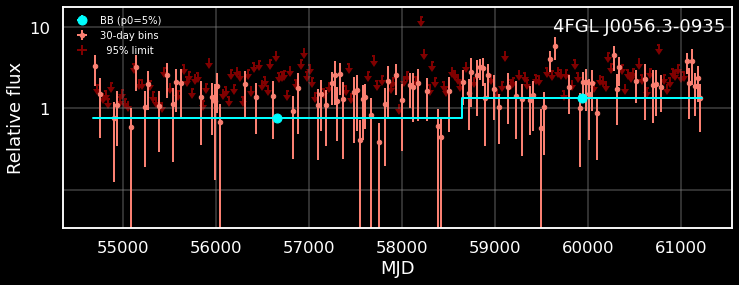

In [9]:
nb.cells[3].outputs